# Exploración de datos y viabilidad del recomendador de estaciones

## Fuentes y alcance

- Catálogo oficial: `https://datos.energia.gob.ar/api/3/action/package_show?id=precios-en-surtidor`
- Datos vigentes: recurso CSV descubierto desde el catálogo.
- Datos históricos: consulta filtrada en el CKAN DataStore para evitar descargar el archivo histórico completo.
- Alcance analizado: Ciudad Autónoma de Buenos Aires, nafta súper y premium.
- Proveedor de rutas: el notebook no realiza llamadas de ruteo; solo estima demanda y contrasta el tamaño de cada solicitud con las restricciones técnicas publicadas.

**Reproducibilidad:** la fecha de ejecución, metadatos del recurso, parámetros y umbrales quedan visibles en las salidas.

In [1]:
from __future__ import annotations

import json
import math
import re
import time
import unicodedata
from io import BytesIO
from urllib.parse import quote

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 120)

CATALOG_URL = "https://datos.energia.gob.ar/api/3/action/package_show?id=precios-en-surtidor"
DATASTORE_SQL_URL = "https://datos.energia.gob.ar/api/3/action/datastore_search_sql"
PROVINCE_VALUE = "CAPITAL FEDERAL"
FRESHNESS_DAYS = 30

# Puertas de viabilidad propuestas. Deben acordarse con docentes y equipo.
MIN_CURRENT_STATIONS = 20
MIN_RECENT_PRICE_ROWS = 40
MIN_HISTORICAL_NAPHTHA_ROWS = 2_000
MIN_HISTORICAL_STATIONS = 20
MIN_HISTORY_MONTHS = 12

# Hipótesis de cursada: ajustar a la realidad del equipo.
TEAM_SIZE = 3
COURSE_WEEKS = 12
HOURS_PER_PERSON_WEEK = 6

# Hipótesis operativa para la POC/MVP. La cuota real del plan debe verificarse autenticado.
EXPECTED_QUERIES_PER_DAY = 40
CANDIDATES_PER_QUERY = 20
MATRIX_REQUESTS_PER_QUERY = 1
ASSUMED_MATRIX_DAILY_QUOTA = 500  # valor de planificación tomado de la propuesta; verificar

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz="UTC")
print("Ejecución UTC:", RUN_TIMESTAMP_UTC.isoformat())

Ejecución UTC: 2026-09-18T14:26:38.369006+00:00


## 1 Descubrimiento de recursos oficiales

El recurso se descubre por nombre y formato en lugar de fijar una URL de descarga. Esto reduce el riesgo de que el notebook falle si el catálogo publica una nueva versión del archivo.

In [2]:
session = requests.Session()
session.headers.update({"User-Agent": "academic-data-exploration/1.0"})

def get_json(url, params=None, timeout=120, retries=3):
    last_error = None
    for attempt in range(retries):
        try:
            response = session.get(url, params=params, timeout=timeout, allow_redirects=True)
            response.raise_for_status()
            payload = response.json()
            if isinstance(payload, dict) and payload.get("success") is False:
                raise RuntimeError(payload)
            return payload
        except Exception as exc:
            last_error = exc
            if attempt + 1 < retries:
                time.sleep(2 ** attempt)
    raise RuntimeError(f"No se pudo consultar {url}: {last_error}")

catalog = get_json(CATALOG_URL)["result"]
resources = pd.DataFrame(catalog["resources"])
display(resources[[c for c in ["name", "format", "last_modified", "size", "datastore_active", "id", "url"] if c in resources]])

def choose_resource(pattern):
    mask = resources["name"].str.contains(pattern, case=False, regex=True, na=False)
    candidates = resources.loc[mask].copy()
    if candidates.empty:
        raise ValueError(f"No se encontró un recurso que coincida con: {pattern}")
    return candidates.sort_values("last_modified", ascending=False).iloc[0]

current_resource = choose_resource(r"vigentes|resoluci")
historical_resource = choose_resource(r"hist.ric")
resource_summary = pd.DataFrame([
    {"recurso": "vigente", "nombre": current_resource["name"], "id": current_resource["id"], "actualizado": current_resource.get("last_modified"), "tamaño_MB": current_resource.get("size", np.nan) / 1e6},
    {"recurso": "histórico", "nombre": historical_resource["name"], "id": historical_resource["id"], "actualizado": historical_resource.get("last_modified"), "tamaño_MB": historical_resource.get("size", np.nan) / 1e6},
])
display(resource_summary)
print("Licencia declarada:", catalog.get("license_title"))

,name,format,last_modified,size,datastore_active,id,url
0,Precios vigentes en surtidor - Resolución 314/2016,CSV,2026-09-18T14:00:28.781536,9274366.0,True,80ac25de-a44a-4445-9215-090cf55cfda5,http://datos.energia.gob.ar/dataset/1c181390-5045-475e-94dc-410429be4b17/resource/80ac25de-a44a-4445-9215-090cf55cfd...
1,Precios históricos,CSV,2026-09-17T15:11:16.874783,775415063.0,True,f8dda0d5-2a9f-4d34-b79b-4e63de3995df,http://datos.energia.gob.ar/dataset/1c181390-5045-475e-94dc-410429be4b17/resource/f8dda0d5-2a9f-4d34-b79b-4e63de3995...
2,Aplicaciones,HTML,None,NaN,False,fb904131-778b-486b-a6ac-9780a2f5dad8,https://preciosensurtidor.energia.gob.ar/


,recurso,nombre,id,actualizado,tamaño_MB
0,vigente,Precios vigentes en surtidor - Resolución 314/2016,80ac25de-a44a-4445-9215-090cf55cfda5,2026-09-18T14:00:28.781536,9.274366
1,histórico,Precios históricos,f8dda0d5-2a9f-4d34-b79b-4e63de3995df,2026-09-17T15:11:16.874783,775.415063


Licencia declarada: CC-BY-4.0


## 2 Descarga y normalización del conjunto vigente

Se descarga el CSV completo porque su tamaño es compatible con una notebook local. El archivo histórico es mucho mayor y se trata mediante consultas filtradas del lado del servidor.

In [3]:
def secure_url(url):
    return re.sub(r"^http://", "https://", str(url))

current_url = secure_url(current_resource["url"])
response = session.get(current_url, timeout=180, allow_redirects=True)
response.raise_for_status()
current_raw = pd.read_csv(BytesIO(response.content), low_memory=False, encoding="utf-8-sig")

def normalize_name(value):
    value = unicodedata.normalize("NFKD", str(value)).encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-z0-9]+", "_", value.lower()).strip("_")

current_raw.columns = [normalize_name(c) for c in current_raw.columns]
current_raw["fecha_vigencia"] = pd.to_datetime(current_raw["fecha_vigencia"], errors="coerce")
for col in ["precio", "latitud", "longitud"]:
    current_raw[col] = pd.to_numeric(current_raw[col], errors="coerce")

is_caba = current_raw["provincia"].astype(str).str.upper().eq(PROVINCE_VALUE)
is_naphtha = current_raw["producto"].astype(str).str.contains("nafta", case=False, na=False)
current_caba = current_raw.loc[is_caba].copy()
current_naphtha = current_raw.loc[is_caba & is_naphtha].copy()

print(f"Filas descargadas: {len(current_raw):,}")
print(f"Filas de CABA: {len(current_caba):,}")
print(f"Filas de nafta en CABA: {len(current_naphtha):,}")
display(current_naphtha.head(3))

Filas descargadas: 36,667
Filas de CABA: 1,630
Filas de nafta en CABA: 732


,indice_tiempo,idempresa,cuit,empresa,direccion,localidad,provincia,region,idproducto,producto,idtipohorario,tipohorario,precio,fecha_vigencia,idempresabandera,empresabandera,latitud,longitud,geojson
926,2026-07,6270,33-70934480-9,ALBERDI 2299 SRL,AV. JUAN B. ALBERDI 2299,CAPITAL FEDERAL,CAPITAL FEDERAL,PAMPEANA,3,Nafta (premium) de más de 95 Ron,2,Diurno,2429.0,2026-07-06 12:04:00,4,SHELL C.A.P.S.A.,-34.630529,-58.459995,"{""type"":""Point"",""coordinates"":[-58.459995,-34.630529]}"
927,2026-07,6270,33-70934480-9,ALBERDI 2299 SRL,AV. JUAN B. ALBERDI 2299,CAPITAL FEDERAL,CAPITAL FEDERAL,PAMPEANA,3,Nafta (premium) de más de 95 Ron,3,Nocturno,2429.0,2026-07-06 12:04:00,4,SHELL C.A.P.S.A.,-34.630529,-58.459995,"{""type"":""Point"",""coordinates"":[-58.459995,-34.630529]}"
928,2026-07,6270,33-70934480-9,ALBERDI 2299 SRL,AV. JUAN B. ALBERDI 2299,CAPITAL FEDERAL,CAPITAL FEDERAL,PAMPEANA,2,Nafta (súper) entre 92 y 95 Ron,2,Diurno,2129.0,2026-07-06 12:04:00,4,SHELL C.A.P.S.A.,-34.630529,-58.459995,"{""type"":""Point"",""coordinates"":[-58.459995,-34.630529]}"


## 3 Cobertura y vigencia

La fecha de referencia es la ejecución del notebook. Una observación se considera reciente si su `fecha_vigencia` está dentro del umbral configurable. Esto no demuestra stock ni confirma el precio en surtidor: solo mide antigüedad de publicación.

,indicador,valor
0,Filas vigentes totales,36667
1,Filas CABA,1630
2,Filas de nafta CABA,732
3,Identificadores de estación con nafta,184
4,Filas de nafta con antigüedad ≤ 30 días,8
5,Estaciones con al menos un precio ≤ 30 días,2
6,Productos de nafta,2


,producto,filas,estaciones,filas_recientes,mediana_edad_dias,precio_mediano
0,Nafta (premium) de más de 95 Ron,364,182,4,405.265722,1639.0
1,Nafta (súper) entre 92 y 95 Ron,368,184,4,411.351486,1356.0


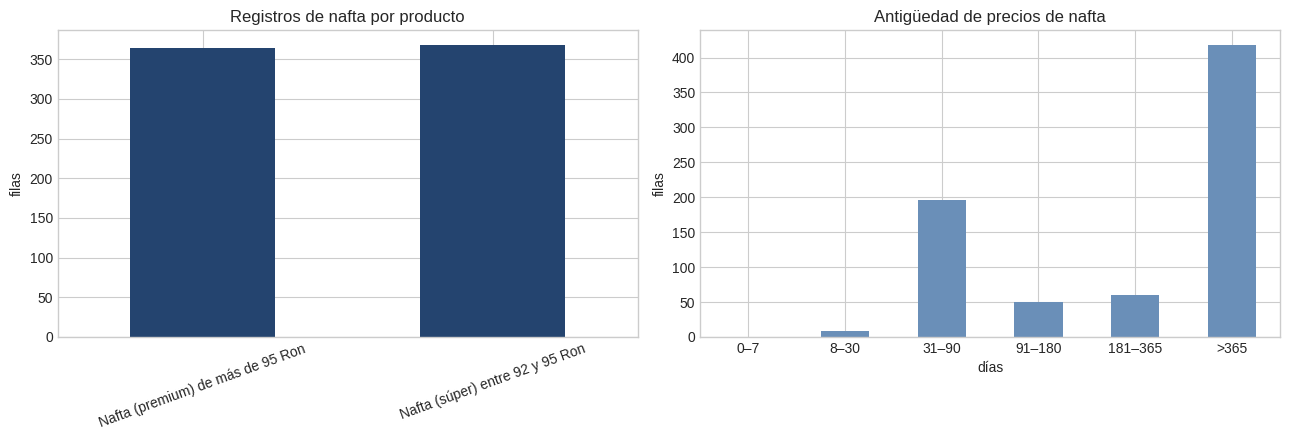

In [4]:
analysis_date = RUN_TIMESTAMP_UTC.tz_localize(None)
current_naphtha["edad_dias"] = (analysis_date - current_naphtha["fecha_vigencia"]).dt.total_seconds() / 86400
current_naphtha["reciente"] = current_naphtha["edad_dias"].between(0, FRESHNESS_DAYS, inclusive="both")

coverage = pd.DataFrame({
    "indicador": [
        "Filas vigentes totales",
        "Filas CABA",
        "Filas de nafta CABA",
        "Identificadores de estación con nafta",
        f"Filas de nafta con antigüedad ≤ {FRESHNESS_DAYS} días",
        f"Estaciones con al menos un precio ≤ {FRESHNESS_DAYS} días",
        "Productos de nafta",
    ],
    "valor": [
        len(current_raw), len(current_caba), len(current_naphtha),
        current_naphtha["idempresa"].nunique(), current_naphtha["reciente"].sum(),
        current_naphtha.loc[current_naphtha["reciente"], "idempresa"].nunique(),
        current_naphtha["producto"].nunique(),
    ]
})
display(coverage)

product_summary = (current_naphtha.groupby("producto", dropna=False)
                   .agg(filas=("idempresa", "size"), estaciones=("idempresa", "nunique"),
                        filas_recientes=("reciente", "sum"), mediana_edad_dias=("edad_dias", "median"),
                        precio_mediano=("precio", "median"))
                   .reset_index())
display(product_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
product_summary.plot.bar(x="producto", y="filas", ax=axes[0], legend=False, color="#24446f", title="Registros de nafta por producto")
axes[0].set_xlabel(""); axes[0].set_ylabel("filas"); axes[0].tick_params(axis="x", rotation=20)
bins = [-1, 7, 30, 90, 180, 365, np.inf]
labels = ["0–7", "8–30", "31–90", "91–180", "181–365", ">365"]
age_groups = pd.cut(current_naphtha["edad_dias"], bins=bins, labels=labels).value_counts().sort_index()
age_groups.plot.bar(ax=axes[1], color="#6a8fb8", title="Antigüedad de precios de nafta")
axes[1].set_xlabel("días"); axes[1].set_ylabel("filas"); axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## 3.1 Estaciones presentes en el conjunto vigente

La fuente publica varias filas por cada `idempresa` porque una misma estación puede informar más de un producto y franja horaria. Para responder qué estaciones aparecen, se construye un catálogo con una fila por identificador, su operador, bandera, dirección, coordenadas, productos y últimos precios publicados.

`idempresa` se utiliza como aproximación a una estación, pero su correspondencia estable con una ubicación física todavía debe confirmarse. Que una estación aparezca en el archivo vigente tampoco implica que su precio sea reciente: ambas poblaciones se muestran por separado.

In [5]:
station_rows = current_naphtha.copy()
station_rows["tipo_nafta"] = np.where(
    station_rows["producto"].str.contains("premium", case=False, na=False),
    "premium",
    "super",
)

# Datos descriptivos tomados de la observación más nueva de cada identificador.
station_identity = (station_rows.sort_values("fecha_vigencia")
                    .drop_duplicates("idempresa", keep="last")
                    [["idempresa", "empresa", "empresabandera", "direccion",
                      "localidad", "latitud", "longitud"]])

# Última observación disponible por estación y tipo de nafta.
latest_product = (station_rows.sort_values("fecha_vigencia")
                  .drop_duplicates(["idempresa", "tipo_nafta"], keep="last"))
price_columns = (latest_product.pivot(index="idempresa", columns="tipo_nafta", values="precio")
                 .rename(columns={"super": "precio_super", "premium": "precio_premium"})
                 .reset_index())

products = (station_rows.groupby("idempresa")["tipo_nafta"]
            .agg(lambda values: ", ".join(sorted(set(values))))
            .rename("productos")
            .reset_index())
latest_dates = (station_rows.groupby("idempresa")["fecha_vigencia"]
                .max().rename("ultima_vigencia").reset_index())

station_catalog = (station_identity.merge(products, on="idempresa", how="left")
                   .merge(price_columns, on="idempresa", how="left")
                   .merge(latest_dates, on="idempresa", how="left"))
station_catalog["edad_ultimo_precio_dias"] = (
    (analysis_date - station_catalog["ultima_vigencia"]).dt.total_seconds() / 86400
).round(1)
station_catalog["tiene_precio_reciente"] = station_catalog["edad_ultimo_precio_dias"].between(
    0, FRESHNESS_DAYS, inclusive="both"
)
station_catalog = station_catalog.sort_values(
    ["tiene_precio_reciente", "empresabandera", "direccion"],
    ascending=[False, True, True],
).reset_index(drop=True)

brand_summary = (station_catalog.groupby("empresabandera", dropna=False)
                 .agg(estaciones=("idempresa", "nunique"),
                      estaciones_con_precio_reciente=("tiene_precio_reciente", "sum"))
                 .sort_values("estaciones", ascending=False)
                 .reset_index())

catalog_columns = ["idempresa", "empresa", "empresabandera", "direccion",
                   "productos", "precio_super", "precio_premium",
                   "ultima_vigencia", "edad_ultimo_precio_dias",
                   "tiene_precio_reciente", "latitud", "longitud"]
recent_station_catalog = station_catalog.loc[
    station_catalog["tiene_precio_reciente"], catalog_columns
]

display(Markdown(f"**Banderas presentes ({len(brand_summary)}):**"))
display(brand_summary)
display(Markdown(
    f"**Estaciones con al menos un precio de hasta {FRESHNESS_DAYS} días "
    f"({len(recent_station_catalog)} de {len(station_catalog)}):**"
))
display(recent_station_catalog)
display(Markdown("**Catálogo completo de identificadores presentes en el archivo vigente:**"))
with pd.option_context("display.max_rows", len(station_catalog)):
    display(station_catalog[catalog_columns])

**Banderas presentes (8):**

,empresabandera,estaciones,estaciones_con_precio_reciente
0,YPF,75,2
1,SHELL C.A.P.S.A.,58,0
2,AXION,31,0
3,BLANCA,8,0
4,PUMA,8,0
5,GULF,2,0
6,DAPSA S.A.,1,0
7,VOY,1,0


**Estaciones con al menos un precio de hasta 30 días (2 de 184):**

,idempresa,empresa,empresabandera,direccion,productos,precio_super,precio_premium,ultima_vigencia,edad_ultimo_precio_dias,tiene_precio_reciente,latitud,longitud
0,1458,SOLMAY S.R.L,YPF,AV. JUAN BAUTISTA ALBERDI 4402,"premium, super",2045.0,2258.0,2026-09-01 17:45:00,16.9,True,-34.64150,-58.48784
1,8314,PROYECTOS SUSTENTABLES S.A.,YPF,LISANDRO DE LA TORRE 2179,"premium, super",2050.0,2257.0,2026-08-28 18:31:00,20.8,True,-34.66008,-58.50346


**Catálogo completo de identificadores presentes en el archivo vigente:**

,idempresa,empresa,empresabandera,direccion,productos,precio_super,precio_premium,ultima_vigencia,edad_ultimo_precio_dias,tiene_precio_reciente,latitud,longitud
0,1458,SOLMAY S.R.L,YPF,AV. JUAN BAUTISTA ALBERDI 4402,"premium, super",2045.0,2258.0,2026-09-01 17:45:00,16.9,True,-34.641500,-58.487840
1,8314,PROYECTOS SUSTENTABLES S.A.,YPF,LISANDRO DE LA TORRE 2179,"premium, super",2050.0,2257.0,2026-08-28 18:31:00,20.8,True,-34.660080,-58.503460
2,2895,ESTADÍAS Y SERVICIOS SA,AXION,ALMAFUERTE 187,"premium, super",2119.0,2429.0,2026-08-12 09:51:00,37.2,False,-34.640530,-58.412520
3,1368,KUKE S.R.L.,AXION,AV DIRECTORIO 1796,"premium, super",989.0,1190.0,2024-06-01 10:56:00,839.1,False,-34.631190,-58.452900
4,1453,EMICAS SRL,AXION,AV. EMILIO CASTRO 7541,"premium, super",1264.0,1531.0,2025-06-01 15:38:00,474.0,False,-34.655620,-58.523646
5,2054,NUEVOS EMPRENDIMIENTOS S.R.L.,AXION,AV. EVA PERON 4350,"premium, super",1087.0,1339.0,2024-10-23 11:23:00,695.1,False,-34.653138,-58.473356
6,9267,"PAN AMERICAN ENERGY LLC, SUCURSAL ARGENTINA",AXION,AV. F. Beiró 5501 esq. Moliere,"premium, super",2119.0,2399.0,2026-08-12 00:00:00,37.6,False,-34.615767,-58.527724
7,2672,OCTOBER S.A.,AXION,AV. WARNES 2040,"premium, super",1299.0,1597.0,2025-06-23 12:45:00,452.1,False,-34.596593,-58.464223
8,9323,"PAN AMERICAN ENERGY LLC, SUCURSAL ARGENTINA",AXION,Autopista Gral. Paz 11200 (esq. Humaitá),"premium, super",2119.0,2399.0,2026-08-12 00:00:00,37.6,False,-34.646530,-58.528820
9,9283,"PAN AMERICAN ENERGY LLC, SUCURSAL ARGENTINA",AXION,Av Los Incas 3550,"premium, super",2119.0,2399.0,2026-08-12 00:00:00,37.6,False,-34.575093,-58.462870


## 4 Calidad del conjunto vigente

Las pruebas siguientes evalúan completitud, validez de coordenadas y precios, y duplicados de la clave lógica candidata. No confirman que `idempresa` represente de forma permanente una estación física; esa identidad se evalúa nuevamente con el histórico.

,columna,faltantes,porcentaje
0,idempresa,0,0.0
1,idproducto,0,0.0
2,idtipohorario,0,0.0
3,producto,0,0.0
4,precio,0,0.0
5,fecha_vigencia,0,0.0
6,latitud,0,0.0
7,longitud,0,0.0


,prueba,cumple,detalle
0,Columnas requeridas presentes,True,8
1,Filas con clave candidata duplicada,True,0
2,Coordenadas dentro de recuadro amplio de CABA,True,0
3,Precios positivos,True,0
4,Fechas interpretables,True,0


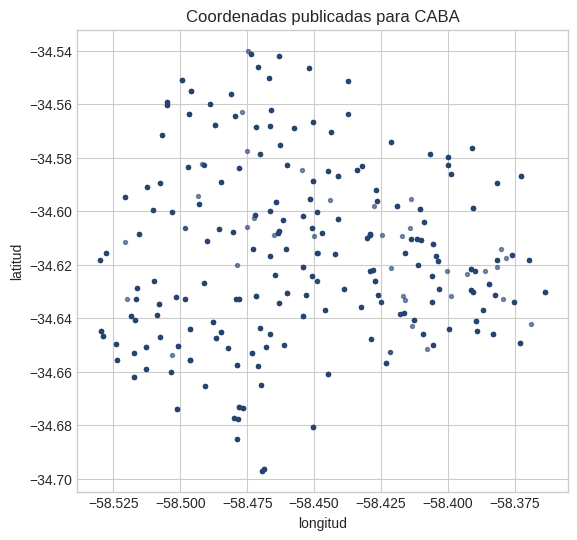

In [6]:
required_columns = ["idempresa", "idproducto", "idtipohorario", "producto", "precio", "fecha_vigencia", "latitud", "longitud"]
missing_report = pd.DataFrame({
    "columna": required_columns,
    "faltantes": [current_naphtha[c].isna().sum() for c in required_columns],
    "porcentaje": [current_naphtha[c].isna().mean() * 100 for c in required_columns],
})

candidate_key = ["idempresa", "idproducto", "idtipohorario"]
duplicated_key_rows = current_naphtha.duplicated(candidate_key, keep=False)
valid_coords = current_naphtha["latitud"].between(-35.0, -34.3) & current_naphtha["longitud"].between(-59.0, -58.2)
positive_price = current_naphtha["precio"].gt(0)

quality_summary = pd.DataFrame([
    ("Columnas requeridas presentes", all(c in current_naphtha.columns for c in required_columns), len(required_columns)),
    ("Filas con clave candidata duplicada", int(duplicated_key_rows.sum()) == 0, int(duplicated_key_rows.sum())),
    ("Coordenadas dentro de recuadro amplio de CABA", bool(valid_coords.all()), int((~valid_coords).sum())),
    ("Precios positivos", bool(positive_price.all()), int((~positive_price).sum())),
    ("Fechas interpretables", bool(current_naphtha["fecha_vigencia"].notna().all()), int(current_naphtha["fecha_vigencia"].isna().sum())),
], columns=["prueba", "cumple", "detalle"])
display(missing_report)
display(quality_summary)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(current_caba["longitud"], current_caba["latitud"], s=8, alpha=.35, color="#24446f")
ax.set(title="Coordenadas publicadas para CABA", xlabel="longitud", ylabel="latitud")
ax.set_aspect("equal", adjustable="box")
plt.show()

## 5 Profundidad y continuidad del histórico

Para mantener razonable el consumo de memoria y red, se consultan desde el DataStore únicamente las filas de CABA correspondientes a nafta. La consulta selecciona las columnas necesarias para evaluar volumen, rango temporal, repetición por estación y variabilidad.

In [7]:
historical_id = historical_resource["id"]

def sql_query(sql, timeout=180):
    payload = get_json(DATASTORE_SQL_URL, params={"sql": sql}, timeout=timeout, retries=3)
    return payload["result"]["records"]

count_sql = f'''SELECT count(*) FROM "{historical_id}"
WHERE provincia = '{PROVINCE_VALUE}' AND lower(producto) LIKE '%nafta%' '''
historical_count = int(sql_query(count_sql)[0]["count"])
print(f"Filas históricas de nafta en CABA informadas por el servidor: {historical_count:,}")

selected = "idempresa, empresa, direccion, localidad, producto, idproducto, idtipohorario, precio, fecha_vigencia, latitud, longitud, empresabandera"
page_size = 10_000
pages = []
for offset in range(0, historical_count, page_size):
    sql = f'''SELECT {selected} FROM "{historical_id}"
    WHERE provincia = '{PROVINCE_VALUE}' AND lower(producto) LIKE '%nafta%'
    ORDER BY fecha_vigencia LIMIT {page_size} OFFSET {offset}'''
    page = pd.DataFrame(sql_query(sql))
    pages.append(page)
    print(f"Recuperadas {min(offset + len(page), historical_count):,} de {historical_count:,}")

historical = pd.concat(pages, ignore_index=True) if pages else pd.DataFrame()
historical["fecha_vigencia"] = pd.to_datetime(historical["fecha_vigencia"], errors="coerce")
for col in ["precio", "latitud", "longitud"]:
    historical[col] = pd.to_numeric(historical[col], errors="coerce")
historical["mes"] = historical["fecha_vigencia"].dt.to_period("M").astype(str)
historical["fecha_futura"] = historical["fecha_vigencia"] > (analysis_date + pd.Timedelta(days=1))
display(historical.head(3))

Filas históricas de nafta en CABA informadas por el servidor: 20,522
Recuperadas 10,000 de 20,522
Recuperadas 20,000 de 20,522
Recuperadas 20,522 de 20,522


,idtipohorario,latitud,empresa,producto,idempresa,precio,direccion,fecha_vigencia,idproducto,empresabandera,localidad,longitud,mes,fecha_futura
0,2,NaN,CASAMASSIMA OMAR Y CAVALLERI JORGE,Nafta (premium) de más de 95 Ron,1236,15.9,AV. LA PLATA 1614,2015-01-07 09:00:00,3,SOL PETROLEO,CAPITAL FEDERAL,NaN,2015-01,False
1,3,NaN,CASAMASSIMA OMAR Y CAVALLERI JORGE,Nafta (premium) de más de 95 Ron,1236,15.9,AV. LA PLATA 1614,2015-01-07 09:00:00,3,SOL PETROLEO,CAPITAL FEDERAL,NaN,2015-01,False
2,2,NaN,CASAMASSIMA OMAR Y CAVALLERI JORGE,Nafta (súper) entre 92 y 95 Ron,1236,14.8,AV. LA PLATA 1614,2015-01-07 09:00:00,2,SOL PETROLEO,CAPITAL FEDERAL,NaN,2015-01,False


,indicador,valor
0,Filas,20522
1,Estaciones,76
2,Fecha mínima,2015-01-07 09:00:00
3,Fecha máxima,2026-10-03 10:03:00
4,Fechas posteriores a la ejecución,84
5,Meses de cobertura,142
6,Mediana de observaciones por estación,320.0
7,Mediana de meses por estación,51.5


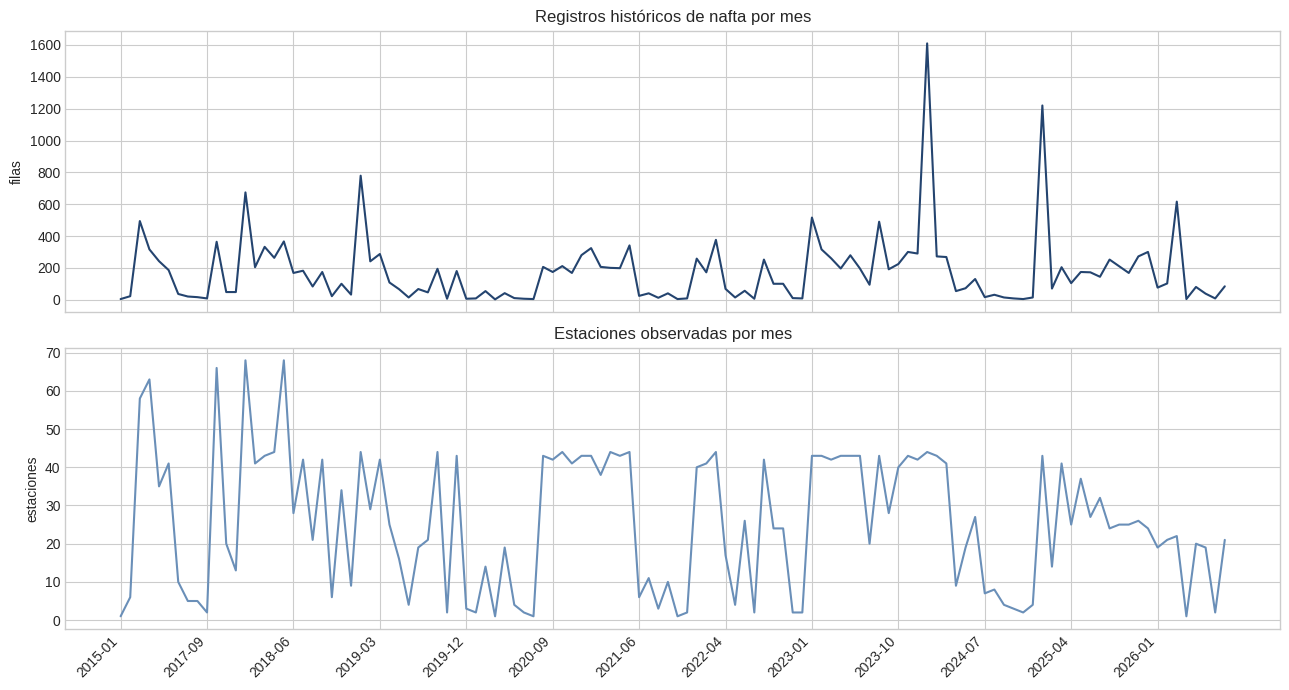

In [8]:
history_span_months = None
if not historical.empty and historical["fecha_vigencia"].notna().any():
    date_min = historical["fecha_vigencia"].min()
    date_max = historical["fecha_vigencia"].max()
    history_span_months = (date_max.to_period("M") - date_min.to_period("M")).n + 1
else:
    date_min = date_max = pd.NaT

station_obs = historical.groupby("idempresa").size()
station_months = historical.groupby("idempresa")["mes"].nunique()
historical_summary = pd.DataFrame({
    "indicador": ["Filas", "Estaciones", "Fecha mínima", "Fecha máxima", "Fechas posteriores a la ejecución", "Meses de cobertura", "Mediana de observaciones por estación", "Mediana de meses por estación"],
    "valor": [len(historical), historical["idempresa"].nunique(), date_min, date_max, int(historical["fecha_futura"].sum()), history_span_months, station_obs.median(), station_months.median()]
})
display(historical_summary)

monthly = historical.groupby("mes").agg(filas=("idempresa", "size"), estaciones=("idempresa", "nunique")).reset_index()
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(monthly["mes"], monthly["filas"], color="#24446f")
axes[0].set_title("Registros históricos de nafta por mes"); axes[0].set_ylabel("filas")
axes[1].plot(monthly["mes"], monthly["estaciones"], color="#6a8fb8")
axes[1].set_title("Estaciones observadas por mes"); axes[1].set_ylabel("estaciones")
step = max(1, len(monthly) // 12)
axes[1].set_xticks(range(0, len(monthly), step)); axes[1].set_xticklabels(monthly["mes"].iloc[::step], rotation=45, ha="right")
plt.tight_layout(); plt.show()

## 6 Identidad de estaciones y riesgo de fuga

Una estación debería mantener razonablemente estable su dirección y ubicación. Los cambios observados no prueban errores: pueden reflejar correcciones, mudanzas o reutilización del identificador. El análisis identifica casos que requieren investigación antes de construir variables históricas.

In [9]:
identity = (historical.groupby("idempresa")
            .agg(filas=("idempresa", "size"), nombres=("empresa", "nunique"), direcciones=("direccion", "nunique"),
                 latitudes=("latitud", "nunique"), longitudes=("longitud", "nunique"),
                 primera_fecha=("fecha_vigencia", "min"), ultima_fecha=("fecha_vigencia", "max"))
            .reset_index())
identity["requiere_revision"] = (identity[["nombres", "direcciones"]].max(axis=1) > 1) | (identity[["latitudes", "longitudes"]].max(axis=1) > 2)

identity_summary = pd.DataFrame({
    "indicador": ["Estaciones históricas", "IDs con más de un nombre", "IDs con más de una dirección", "IDs marcados para revisión"],
    "valor": [len(identity), (identity["nombres"] > 1).sum(), (identity["direcciones"] > 1).sum(), identity["requiere_revision"].sum()]
})
display(identity_summary)
display(identity.sort_values(["requiere_revision", "direcciones", "nombres"], ascending=False).head(15))

display(Markdown('''
**Regla para modelado:** cualquier agregado histórico debe calcularse usando solo registros anteriores a la fecha objetivo. Los cortes de entrenamiento y validación deben ser temporales, y los registros equivalentes de una misma estación, producto y franja no deben repartirse entre ambos conjuntos.
'''))

,indicador,valor
0,Estaciones históricas,76
1,IDs con más de un nombre,0
2,IDs con más de una dirección,0
3,IDs marcados para revisión,0


,idempresa,filas,nombres,direcciones,latitudes,longitudes,primera_fecha,ultima_fecha,requiere_revision
0,11096,176,1,1,1,1,2024-01-10 00:00:00,2026-10-03 00:00:00,False
1,1236,6,1,1,0,0,2015-01-07 09:00:00,2019-07-23 12:36:00,False
2,1285,368,1,1,1,1,2017-02-07 08:00:00,2025-07-20 00:00:00,False
3,130,200,1,1,1,1,2017-01-08 14:00:00,2022-03-14 09:00:00,False
4,1556,438,1,1,1,1,2017-06-11 10:16:00,2026-06-01 13:48:00,False
5,1864,244,1,1,1,1,2017-04-12 15:04:00,2025-07-16 15:24:00,False
6,2230,351,1,1,1,1,2017-02-07 00:00:00,2025-05-14 00:00:00,False
7,2692,402,1,1,1,1,2017-03-07 12:42:00,2026-09-01 14:09:00,False
8,2728,78,1,1,1,1,2017-01-31 12:34:00,2019-07-03 14:00:00,False
9,3264,355,1,1,1,1,2017-02-07 00:00:00,2025-05-14 00:00:00,False



**Regla para modelado:** cualquier agregado histórico debe calcularse usando solo registros anteriores a la fecha objetivo. Los cortes de entrenamiento y validación deben ser temporales, y los registros equivalentes de una misma estación, producto y franja no deben repartirse entre ambos conjuntos.


## 7 Señal estadística preliminar

Este bloque no entrena el modelo final. Evalúa si existen volumen, repetición y variación suficientes para justificar una POC. Los precios nominales a lo largo de varios años no deben compararse sin contexto temporal; por eso se observan distribuciones por mes y producto.

,mes,producto,observaciones,estaciones,mediana,q25,q75,iqr
218,2026-02,Nafta (súper) entre 92 y 95 Ron,52,21,1699.0,1683.0,1731.0,48.0
219,2026-03,Nafta (premium) de más de 95 Ron,292,22,2199.0,2099.0,2299.0,200.0
220,2026-03,Nafta (súper) entre 92 y 95 Ron,324,22,1930.0,1853.0,1999.0,146.0
221,2026-04,Nafta (premium) de más de 95 Ron,2,1,1922.0,1922.0,1922.0,0.0
222,2026-04,Nafta (súper) entre 92 y 95 Ron,2,1,1672.0,1672.0,1672.0,0.0
223,2026-06,Nafta (premium) de más de 95 Ron,40,20,1965.5,1941.0,1971.0,30.0
224,2026-06,Nafta (súper) entre 92 y 95 Ron,40,20,1682.0,1665.0,1682.0,17.0
225,2026-07,Nafta (súper) entre 92 y 95 Ron,38,19,1754.0,1734.0,1754.0,20.0
226,2026-09,Nafta (premium) de más de 95 Ron,4,2,1937.5,1934.0,1941.0,7.0
227,2026-09,Nafta (súper) entre 92 y 95 Ron,4,2,1665.0,1665.0,1665.0,0.0


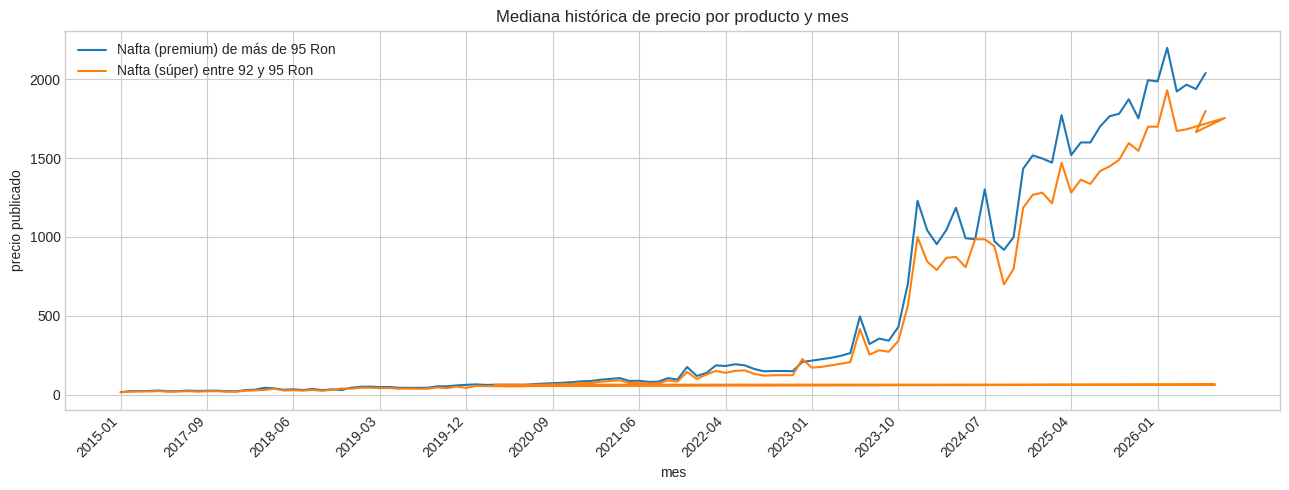

In [10]:
price_profile = (historical.groupby(["mes", "producto"])
                 .agg(observaciones=("precio", "count"), estaciones=("idempresa", "nunique"),
                      mediana=("precio", "median"), q25=("precio", lambda s: s.quantile(.25)), q75=("precio", lambda s: s.quantile(.75)))
                 .reset_index())
price_profile["iqr"] = price_profile["q75"] - price_profile["q25"]
display(price_profile.tail(12))

fig, ax = plt.subplots(figsize=(13, 5))
for product, group in price_profile.groupby("producto"):
    ax.plot(group["mes"], group["mediana"], label=product)
step = max(1, price_profile["mes"].nunique() // 12)
labels = sorted(price_profile["mes"].unique())
ax.set_xticks(range(0, len(labels), step)); ax.set_xticklabels(labels[::step], rotation=45, ha="right")
ax.set(title="Mediana histórica de precio por producto y mes", ylabel="precio publicado", xlabel="mes")
ax.legend(); plt.tight_layout(); plt.show()

## 8 Puertas de viabilidad de datos

Los umbrales son criterios de trabajo, no hechos del conjunto. Cambiarlos permite documentar cómo varía la conclusión. Una puerta aprobada significa que vale la pena avanzar con la POC; no garantiza desempeño predictivo.

In [11]:
recent_rows = int(current_naphtha["reciente"].sum())
recent_stations = int(current_naphtha.loc[current_naphtha["reciente"], "idempresa"].nunique())

data_gates = pd.DataFrame([
    ("Cobertura reciente", recent_rows, f">= {MIN_RECENT_PRICE_ROWS} filas", recent_rows >= MIN_RECENT_PRICE_ROWS,
     "Si falla, informar cobertura insuficiente y usar escenario histórico rotulado."),
    ("Estaciones actuales", recent_stations, f">= {MIN_CURRENT_STATIONS} estaciones", recent_stations >= MIN_CURRENT_STATIONS,
     "Reducir candidatas y usar una captura verificada para la demostración."),
    ("Volumen histórico", len(historical), f">= {MIN_HISTORICAL_NAPHTHA_ROWS} filas", len(historical) >= MIN_HISTORICAL_NAPHTHA_ROWS,
     "Ampliar entrenamiento a nivel nacional y conservar evaluación específica en CABA."),
    ("Estaciones históricas", historical["idempresa"].nunique(), f">= {MIN_HISTORICAL_STATIONS} estaciones", historical["idempresa"].nunique() >= MIN_HISTORICAL_STATIONS,
     "Usar baseline por zona/producto o limitar el objetivo del componente ML."),
    ("Profundidad temporal", history_span_months, f">= {MIN_HISTORY_MONTHS} meses", (history_span_months or 0) >= MIN_HISTORY_MONTHS,
     "Reducir complejidad, usar regresión regularizada y reportar incertidumbre."),
    ("Consistencia de fechas", int(historical["fecha_futura"].sum()), "0 fechas posteriores a la ejecución", int(historical["fecha_futura"].sum()) == 0,
     "Confirmar la interpretación día/mes entre CSV y API antes de entrenar o unir fuentes."),
], columns=["puerta", "observado", "criterio_propuesto", "cumple", "plan_b"])
display(data_gates)

,puerta,observado,criterio_propuesto,cumple,plan_b
0,Cobertura reciente,8,>= 40 filas,False,"Si falla, informar cobertura insuficiente y usar escenario histórico rotulado."
1,Estaciones actuales,2,>= 20 estaciones,False,Reducir candidatas y usar una captura verificada para la demostración.
2,Volumen histórico,20522,>= 2000 filas,True,Ampliar entrenamiento a nivel nacional y conservar evaluación específica en CABA.
3,Estaciones históricas,76,>= 20 estaciones,True,Usar baseline por zona/producto o limitar el objetivo del componente ML.
4,Profundidad temporal,142,>= 12 meses,True,"Reducir complejidad, usar regresión regularizada y reportar incertidumbre."
5,Consistencia de fechas,84,0 fechas posteriores a la ejecución,False,Confirmar la interpretación día/mes entre CSV y API antes de entrenar o unir fuentes.


## 9 Viabilidad del proveedor de rutas

El diseño preselecciona geográficamente hasta veinte estaciones y puede enviar una matriz de origen/destino en una sola solicitud. Las restricciones técnicas publicadas permiten matrices mayores que este caso, pero las cuotas diarias dependen del plan y deben verificarse con una prueba autenticada.

In [12]:
locations_per_request = CANDIDATES_PER_QUERY + 2  # origen, candidatas y destino opcional
estimated_matrix_requests = EXPECTED_QUERIES_PER_DAY * MATRIX_REQUESTS_PER_QUERY
quota_usage = estimated_matrix_requests / ASSUMED_MATRIX_DAILY_QUOTA if ASSUMED_MATRIX_DAILY_QUOTA else np.nan

route_budget = pd.DataFrame([
    ("Candidatas por consulta", CANDIDATES_PER_QUERY, "Máximo del MVP"),
    ("Ubicaciones aproximadas por matriz", locations_per_request, "Origen + destino + candidatas"),
    ("Consultas de usuario por día", EXPECTED_QUERIES_PER_DAY, "Supuesto de POC; ajustar"),
    ("Solicitudes Matrix estimadas por día", estimated_matrix_requests, "Una matriz por consulta"),
    ("Cuota diaria asumida", ASSUMED_MATRIX_DAILY_QUOTA, "Dato de planificación; verificar autenticado"),
    ("Uso estimado de cuota", f"{quota_usage:.1%}", "Debe dejar margen para pruebas y reintentos"),
], columns=["variable", "valor", "interpretacion"])
display(route_budget)

route_gate = bool(locations_per_request <= 25 and estimated_matrix_requests <= ASSUMED_MATRIX_DAILY_QUOTA * 0.8)
print("Puerta operativa preliminar:", "CUMPLE" if route_gate else "REVISAR")
print("Plan B: reducir candidatas, cachear resultados permitido por condiciones de uso y evaluar OSRM regional.")

,variable,valor,interpretacion
0,Candidatas por consulta,20,Máximo del MVP
1,Ubicaciones aproximadas por matriz,22,Origen + destino + candidatas
2,Consultas de usuario por día,40,Supuesto de POC; ajustar
3,Solicitudes Matrix estimadas por día,40,Una matriz por consulta
4,Cuota diaria asumida,500,Dato de planificación; verificar autenticado
5,Uso estimado de cuota,8.0%,Debe dejar margen para pruebas y reintentos


Puerta operativa preliminar: CUMPLE
Plan B: reducir candidatas, cachear resultados permitido por condiciones de uso y evaluar OSRM regional.


## 10 Viabilidad con recursos y tiempos de la cursada

Este presupuesto es deliberadamente explícito para que pueda discutirse. No representa horas reales del equipo hasta que se actualicen los parámetros iniciales.

In [13]:
work_plan = pd.DataFrame([
    ("Datos e ingesta", 38, "Descarga, normalización, calidad, trazabilidad"),
    ("Motor de recomendación y API", 48, "Reglas, rutas, explicaciones y contratos"),
    ("Interfaz web", 30, "Formulario, rankings, errores y advertencias"),
    ("POC y ciclo de ML", 42, "Features temporales, baseline, modelos, evaluación y serving"),
    ("Infraestructura y observabilidad", 24, "Contenedores, CI/CD, configuración, métricas"),
    ("Integración, pruebas y documentación", 32, "Pruebas E2E, demo y memoria técnica"),
], columns=["frente", "horas_estimadas", "entregable"])

available_hours = TEAM_SIZE * COURSE_WEEKS * HOURS_PER_PERSON_WEEK
planned_hours = int(work_plan["horas_estimadas"].sum())
contingency = available_hours - planned_hours
schedule_gate = contingency >= available_hours * 0.10

display(work_plan)
display(pd.DataFrame([
    ("Personas", TEAM_SIZE), ("Semanas", COURSE_WEEKS), ("Horas por persona y semana", HOURS_PER_PERSON_WEEK),
    ("Capacidad total", available_hours), ("Horas planificadas", planned_hours),
    ("Margen", contingency), ("Margen porcentual", f"{contingency/available_hours:.1%}"),
], columns=["variable", "valor"]))
print("Puerta de cronograma:", "CUMPLE" if schedule_gate else "REQUIERE RECORTE")

,frente,horas_estimadas,entregable
0,Datos e ingesta,38,"Descarga, normalización, calidad, trazabilidad"
1,Motor de recomendación y API,48,"Reglas, rutas, explicaciones y contratos"
2,Interfaz web,30,"Formulario, rankings, errores y advertencias"
3,POC y ciclo de ML,42,"Features temporales, baseline, modelos, evaluación y serving"
4,Infraestructura y observabilidad,24,"Contenedores, CI/CD, configuración, métricas"
5,"Integración, pruebas y documentación",32,"Pruebas E2E, demo y memoria técnica"


,variable,valor
0,Personas,3
1,Semanas,12
2,Horas por persona y semana,6
3,Capacidad total,216
4,Horas planificadas,214
5,Margen,2
6,Margen porcentual,0.9%


Puerta de cronograma: REQUIERE RECORTE


## 11 Supuestos fuertes y planes B

In [14]:
assumptions = pd.DataFrame([
    ("Identidad", "idempresa representa de manera suficientemente estable una estación física.",
     "Revisar IDs con cambios de nombre, dirección o coordenadas; crear una clave canónica documentada."),
    ("Vigencia", f"Un precio con hasta {FRESHNESS_DAYS} días sirve para generar una recomendación académica.",
     "Si la cobertura reciente es baja, no recomendar como actual; usar escenarios históricos rotulados."),
    ("Histórico", "El histórico tiene profundidad y repetición suficientes para validación temporal.",
     "Ampliar el entrenamiento a Argentina y mantener un test separado de CABA."),
    ("Modelo", "Un modelo supervisado mejora de forma estable a la mediana por producto, zona y período.",
     "Usar regresión regularizada o conservar el baseline como diagnóstico estadístico explícito."),
    ("Rutas", "La cuota autenticada admite el flujo académico con margen.",
     "Reducir candidatas, usar caché compatible y evaluar OSRM con extracto regional."),
    ("Entradas", "El usuario informa consumo, litros restantes y capacidad con precisión útil.",
     "Validar rangos, ofrecer ayudas y comunicar que el resultado es estimativo."),
    ("Cronograma", "La disponibilidad real del equipo coincide con los parámetros cargados.",
     "Priorizar POC integral; postergar panel administrativo, cloud completo y modelo complejo."),
], columns=["area", "supuesto_fuerte", "plan_b"])
display(assumptions)

,area,supuesto_fuerte,plan_b
0,Identidad,idempresa representa de manera suficientemente estable una estación física.,"Revisar IDs con cambios de nombre, dirección o coordenadas; crear una clave canónica documentada."
1,Vigencia,Un precio con hasta 30 días sirve para generar una recomendación académica.,"Si la cobertura reciente es baja, no recomendar como actual; usar escenarios históricos rotulados."
2,Histórico,El histórico tiene profundidad y repetición suficientes para validación temporal.,Ampliar el entrenamiento a Argentina y mantener un test separado de CABA.
3,Modelo,"Un modelo supervisado mejora de forma estable a la mediana por producto, zona y período.",Usar regresión regularizada o conservar el baseline como diagnóstico estadístico explícito.
4,Rutas,La cuota autenticada admite el flujo académico con margen.,"Reducir candidatas, usar caché compatible y evaluar OSRM con extracto regional."
5,Entradas,"El usuario informa consumo, litros restantes y capacidad con precisión útil.","Validar rangos, ofrecer ayudas y comunicar que el resultado es estimativo."
6,Cronograma,La disponibilidad real del equipo coincide con los parámetros cargados.,"Priorizar POC integral; postergar panel administrativo, cloud completo y modelo complejo."


## 12 Conclusión reproducible

La conclusión combina puertas técnicas y de planificación. Debe leerse junto con los riesgos: “viable” significa que hay evidencia suficiente para avanzar con el alcance controlado, no que todos los supuestos hayan sido demostrados.

In [16]:
all_data_gates = bool(data_gates["cumple"].all())
overall_viable = all_data_gates and route_gate and schedule_gate

verdict = "VIABLE PARA AVANZAR CON EL ALCANCE PROPUESTO" if overall_viable else "VIABLE CON CONDICIONES Y/O RECORTE DE ALCANCE"
display(Markdown(f"## Dictamen: {verdict}"))

decision = pd.DataFrame([
    ("Datos vigentes e históricos", all_data_gates, "Revisar puertas fallidas y aplicar su plan B."),
    ("Proveedor de rutas", route_gate, "Confirmar cuota con una prueba autenticada."),
    ("Tiempo de cursada", schedule_gate, "Actualizar personas, semanas y disponibilidad real."),
], columns=["dimension", "cumple", "accion_pendiente"])
display(decision)

failed = data_gates.loc[~data_gates["cumple"], ["puerta", "plan_b"]]
if not failed.empty:
    display(Markdown("### Planes B activados por los datos observados"))
    display(failed)

display(Markdown(f'''

El análisis se ejecutó el **{RUN_TIMESTAMP_UTC.strftime('%Y-%m-%d')}** sobre los recursos oficiales descubiertos desde el catálogo. Para CABA se observaron **{len(current_naphtha):,} registros vigentes de nafta**, correspondientes a **{current_naphtha['idempresa'].nunique():,} identificadores de estación**. De ellos, **{recent_rows:,} registros** y **{recent_stations:,} estaciones** se encontraban dentro del umbral propuesto de **{FRESHNESS_DAYS} días**. El histórico filtrado reunió **{len(historical):,} observaciones**, **{historical['idempresa'].nunique():,} estaciones** y aproximadamente **{history_span_months} meses** de cobertura.

Con los umbrales explicitados en este notebook, el dictamen es **{verdict.lower()}**. Persisten como supuestos fuertes la estabilidad de `idempresa`, la interpretación de fechas, la utilidad del umbral de vigencia, la mejora del modelo frente al baseline y la cuota real del proveedor de rutas. Cada supuesto cuenta con un plan B documentado y el producto debe comunicar cobertura insuficiente en lugar de presentar datos antiguos como actuales.
'''))

## Dictamen: VIABLE CON CONDICIONES Y/O RECORTE DE ALCANCE

,dimension,cumple,accion_pendiente
0,Datos vigentes e históricos,False,Revisar puertas fallidas y aplicar su plan B.
1,Proveedor de rutas,True,Confirmar cuota con una prueba autenticada.
2,Tiempo de cursada,False,"Actualizar personas, semanas y disponibilidad real."


### Planes B activados por los datos observados

,puerta,plan_b
0,Cobertura reciente,"Si falla, informar cobertura insuficiente y usar escenario histórico rotulado."
1,Estaciones actuales,Reducir candidatas y usar una captura verificada para la demostración.
5,Consistencia de fechas,Confirmar la interpretación día/mes entre CSV y API antes de entrenar o unir fuentes.




El análisis se ejecutó el **2026-09-18** sobre los recursos oficiales descubiertos desde el catálogo. Para CABA se observaron **732 registros vigentes de nafta**, correspondientes a **184 identificadores de estación**. De ellos, **8 registros** y **2 estaciones** se encontraban dentro del umbral propuesto de **30 días**. El histórico filtrado reunió **20,522 observaciones**, **76 estaciones** y aproximadamente **142 meses** de cobertura.

Con los umbrales explicitados en este notebook, el dictamen es **viable con condiciones y/o recorte de alcance**. Persisten como supuestos fuertes la estabilidad de `idempresa`, la interpretación de fechas, la utilidad del umbral de vigencia, la mejora del modelo frente al baseline y la cuota real del proveedor de rutas. Cada supuesto cuenta con un plan B documentado y el producto debe comunicar cobertura insuficiente en lugar de presentar datos antiguos como actuales.


## 13 Limitaciones del análisis

- La exploración valida estructura, cobertura y señales estadísticas, pero no verifica físicamente cada estación.
- Una fecha reciente no garantiza stock ni confirma el precio actual; una fecha antigua no prueba que sea incorrecto.
- La identidad de estaciones debe confirmarse documentalmente además de analizarse empíricamente.
- Los umbrales de viabilidad y las horas estimadas son decisiones del proyecto y deben aprobarse.
- La capacidad predictiva solo puede concluirse después de construir features sin información futura y comparar modelos con el baseline mediante validación temporal.
- Las cuotas y condiciones del proveedor de rutas deben verificarse en la cuenta que usará el proyecto.